<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Solutions - Loss Functions and the Hybrid Training Loop

_Prepared by Claudia Zendejas-Morales_

This notebook contains complete solutions for the embedded tasks in notebook `3.1`.


<a id="task1-solution"></a>

## Task 1 (coding): One complete solution

We keep the batch fixed and compare two candidate parameter vectors. The goal is to see that the same circuit family can be preferred differently depending on whether the objective emphasizes calibrated probabilities or signed margins.


In [1]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector

np.set_printoptions(precision=4, suppress=True)

Z0_OP = SparsePauliOp.from_list([("IZ", 1.0)])

def variational_circuit(sample, weights):
    qc = QuantumCircuit(2)
    qc.ry(float(sample[0]), 0)
    qc.ry(float(sample[1]), 1)
    qc.cx(0, 1)
    qc.ry(float(weights[0]), 0)
    qc.ry(float(weights[1]), 1)
    return qc

def exact_score(sample, weights):
    state = Statevector.from_instruction(variational_circuit(sample, weights))
    return float(np.real(state.expectation_value(Z0_OP)))

def batch_scores(X, weights):
    return np.array([exact_score(sample, weights) for sample in X], dtype=float)

def probabilities_from_scores(scores, eps=1e-9):
    probs = 0.5 * (1.0 + np.asarray(scores, dtype=float))
    return np.clip(probs, eps, 1.0 - eps)

def signed_labels(y_binary):
    y_binary = np.asarray(y_binary, dtype=int)
    return 2 * y_binary - 1

def binary_cross_entropy_per_sample(y_true, probs):
    y_true = np.asarray(y_true, dtype=float)
    probs = np.asarray(probs, dtype=float)
    return -(y_true * np.log(probs) + (1.0 - y_true) * np.log(1.0 - probs))

def hinge_loss_per_sample(y_true_pm, scores):
    y_true_pm = np.asarray(y_true_pm, dtype=float)
    scores = np.asarray(scores, dtype=float)
    return np.maximum(0.0, 1.0 - y_true_pm * scores)


In [2]:
samples_task = np.array([
    [0.20, 0.10],
    [0.45, 0.80],
    [0.95, 0.35],
    [1.10, 1.05],
    [1.40, 0.55],
])
y_task = np.array([0, 1, 1, 0, 1])
weights_A = np.array([1.00, -0.70])
weights_B = np.array([-0.35, 0.20])
y_task_pm = signed_labels(y_task)

def summarize_candidate(weights):
    scores = batch_scores(samples_task, weights)
    probs = probabilities_from_scores(scores)
    bce = binary_cross_entropy_per_sample(y_task, probs)
    hinge = hinge_loss_per_sample(y_task_pm, scores)
    return {
        "weights": weights,
        "scores": scores,
        "probs": probs,
        "bce": bce,
        "hinge": hinge,
        "mean_bce": float(np.mean(bce)),
        "mean_hinge": float(np.mean(hinge)),
    }

summary_A = summarize_candidate(weights_A)
summary_B = summarize_candidate(weights_B)

for name, summary in [("A", summary_A), ("B", summary_B)]:
    print(f"Candidate {name} with weights {summary['weights']}")
    print("scores:", np.round(summary["scores"], 4))
    print("probabilities:", np.round(summary["probs"], 4))
    print("BCE per sample:", np.round(summary["bce"], 4))
    print("hinge per sample:", np.round(summary["hinge"], 4))
    print("mean BCE:", summary["mean_bce"])
    print("mean hinge:", summary["mean_hinge"])
    print()

preferred_bce = "A" if summary_A["mean_bce"] < summary_B["mean_bce"] else "B"
preferred_hinge = "A" if summary_A["mean_hinge"] < summary_B["mean_hinge"] else "B"

bce_change = np.abs(summary_A["bce"] - summary_B["bce"])
hinge_change = np.abs(summary_A["hinge"] - summary_B["hinge"])

print("Preferred by BCE:", preferred_bce)
print("Preferred by hinge:", preferred_hinge)
print("Largest BCE change at sample index:", int(np.argmax(bce_change)))
print("Largest hinge change at sample index:", int(np.argmax(hinge_change)))
print("Absolute BCE changes:", np.round(bce_change, 4))
print("Absolute hinge changes:", np.round(hinge_change, 4))


Candidate A with weights [ 1.  -0.7]
scores: [ 0.5128  0.224   0.0796 -0.4054 -0.3416]
probabilities: [0.7564 0.612  0.5398 0.2973 0.3292]
BCE per sample: [1.4123 0.4911 0.6166 0.3528 1.1111]
hinge per sample: [1.5128 0.776  0.9204 0.5946 1.3416]
mean BCE: 0.7967672296510934
mean hinge: 1.029095119736793

Candidate B with weights [-0.35  0.2 ]
scores: [0.9274 0.9528 0.6421 0.6912 0.3363]
probabilities: [0.9637 0.9764 0.821  0.8456 0.6681]
BCE per sample: [3.3166 0.0239 0.1972 1.8681 0.4033]
hinge per sample: [1.9274 0.0472 0.3579 1.6912 0.6637]
mean BCE: 1.1618091528041592
mean hinge: 0.9374868427925783

Preferred by BCE: A
Preferred by hinge: B
Largest BCE change at sample index: 0
Largest hinge change at sample index: 3
Absolute BCE changes: [1.9043 0.4672 0.4194 1.5153 0.7078]
Absolute hinge changes: [0.4146 0.7289 0.5625 1.0966 0.6779]


BCE prefers candidate A because its average cross-entropy is smaller, even though some margins remain weak. Hinge prefers candidate B because its average signed-margin penalty is smaller, despite the fact that candidate B is confidently wrong on some negatively labeled samples.

The largest BCE change appears at the sample where one candidate assigns a very confident but incorrect probability, which cross-entropy punishes strongly. The largest hinge change can come from a different sample, because hinge only tracks whether the signed score clears the unit margin. This is the structural lesson: probability-based objectives and margin-based objectives can apply different optimization pressure to the same quantum readout values.


<a id="task2-solution"></a>

## Task 2 (coding): One complete solution

The circuit stays fixed. This solution reuses the score helpers (functions) defined in Task 1, computes the scores once, and then fits the best affine regression head on top of those scores by least squares.


In [3]:
def mse_loss_per_sample(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return (y_true - y_pred) ** 2

def regression_head(scores, offset=0.5, scale=0.5):
    return offset + scale * np.asarray(scores, dtype=float)

samples_task = np.array([
    [0.12, 0.18],
    [0.52, 0.68],
    [0.98, 0.42],
    [1.28, 0.88],
    [1.45, 0.60],
])
y_task = np.array([0.08, 0.76, 0.62, 0.18, 0.48])
weights_task = np.array([0.35, -0.25])

scores_task = batch_scores(samples_task, weights_task)
A = np.column_stack([np.ones_like(scores_task), scores_task])
a_fit, b_fit = np.linalg.lstsq(A, y_task, rcond=None)[0]

preds_fit = a_fit + b_fit * scores_task
preds_default = regression_head(scores_task, offset=0.50, scale=0.50)

mse_fit = mse_loss_per_sample(y_task, preds_fit)
mse_default = mse_loss_per_sample(y_task, preds_default)

print("shared scores:", np.round(scores_task, 4))
print("fitted offset a:", float(a_fit))
print("fitted slope b:", float(b_fit))
print("fitted-head predictions:", np.round(preds_fit, 4))
print("default-head predictions:", np.round(preds_default, 4))
print("mean MSE fitted head:", float(np.mean(mse_fit)))
print("mean MSE default head:", float(np.mean(mse_default)))


shared scores: [ 0.9253  0.7081  0.4071  0.0161 -0.079 ]
fitted offset a: 0.4287329715807237
fitted slope b: -0.011966398370441115
fitted-head predictions: [0.4177 0.4203 0.4239 0.4285 0.4297]
default-head predictions: [0.9626 0.854  0.7036 0.5081 0.4605]
mean MSE fitted head: 0.06644259069425386
mean MSE default head: 0.18057611984819727


The least-squares head achieves a substantially smaller mean MSE than the default bounded head, even though the quantum circuit never changes. That is the main point of the exercise: once the quantum scores are fixed, a large part of the regression quality can still depend on how the head is chosen.

Here the fitted slope is very close to zero and slightly negative. That means these particular scores are only weakly informative for the given regression targets, so the best affine fit is forced to behave almost like a constant predictor. In other words, the head can improve the numerical fit, but it cannot create information that is not already present in the scalar quantum readout.


<a id="task3-solution"></a>

## Task 3 (coding): One complete solution

We compare the same coordinate-search training loop under full-batch and mini-batch updates. This solution reuses `batch_scores(...)`, `probabilities_from_scores(...)`, and `binary_cross_entropy_per_sample(...)` from the earlier tasks, and then packages the comparison into a reusable experiment function so that the metrics and curves can be analyzed side by side.


In [4]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=120, noise=0.18, random_state=21)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=21, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=21, stratify=y_train_val
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def mean_binary_cross_entropy(X_batch, y_batch, weights):
    scores = batch_scores(X_batch, weights)
    probs = probabilities_from_scores(scores)
    return float(np.mean(binary_cross_entropy_per_sample(y_batch, probs)))

def predict_probabilities(X_batch, weights):
    return probabilities_from_scores(batch_scores(X_batch, weights))

def predict_labels(X_batch, weights, threshold=0.5):
    probs = predict_probabilities(X_batch, weights)
    return (probs >= threshold).astype(int)

def iterate_batches(X_data, y_data, batch_size, rng):
    if batch_size is None or batch_size >= len(X_data):
        yield X_data, y_data
        return

    order = rng.permutation(len(X_data))
    for start in range(0, len(order), batch_size):
        batch_ids = order[start:start + batch_size]
        yield X_data[batch_ids], y_data[batch_ids]

def coordinate_search_step(weights, X_batch, y_batch, step_size):
    current_loss = mean_binary_cross_entropy(X_batch, y_batch, weights)
    best_weights = weights.copy()
    best_loss = current_loss

    for idx in range(len(weights)):
        for direction in (+1.0, -1.0):
            trial = weights.copy()
            trial[idx] += direction * step_size
            trial_loss = mean_binary_cross_entropy(X_batch, y_batch, trial)
            if trial_loss < best_loss:
                best_weights = trial
                best_loss = trial_loss

    return best_weights, best_loss

def train_coordinate_search(
    X_train,
    y_train,
    X_val,
    y_val,
    initial_weights,
    epochs=32,
    batch_size=24,
    initial_step_size=0.40,
    seed=7,
):
    rng = np.random.default_rng(seed)
    weights = np.array(initial_weights, dtype=float)
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        step_size = initial_step_size / np.sqrt(epoch + 1.0)
        for X_batch, y_batch in iterate_batches(X_train, y_train, batch_size, rng):
            weights, _ = coordinate_search_step(weights, X_batch, y_batch, step_size)

        history["train_loss"].append(mean_binary_cross_entropy(X_train, y_train, weights))
        history["val_loss"].append(mean_binary_cross_entropy(X_val, y_val, weights))

    return weights, history


full-batch
  weights: [-1.1912 -0.0367]
  final train loss: 0.762
  final validation loss: 0.5755
  test BCE: 0.8099
  test accuracy: 0.5
  best validation epoch: 30

mini-batch
  weights: [ 2.0267 -0.4592]
  final train loss: 0.811
  final validation loss: 1.0682
  test BCE: 0.8424
  test accuracy: 0.5
  best validation epoch: 1



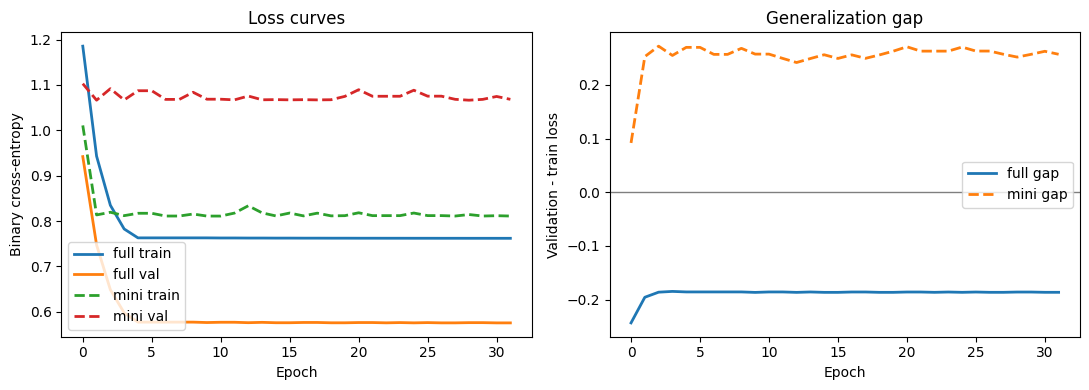

In [5]:
initial_weights = np.array([0.20, -0.20])

def run_experiment(batch_size):
    weights, history = train_coordinate_search(
        X_train,
        y_train,
        X_val,
        y_val,
        initial_weights=initial_weights,
        epochs=32,
        batch_size=batch_size,
        initial_step_size=0.40,
        seed=7,
    )

    test_bce = mean_binary_cross_entropy(X_test, y_test, weights)
    test_acc = accuracy_score(y_test, predict_labels(X_test, weights))
    train_loss = np.array(history["train_loss"], dtype=float)
    val_loss = np.array(history["val_loss"], dtype=float)
    gap = val_loss - train_loss
    best_epoch = int(np.argmin(val_loss))

    return {
        "batch_size": batch_size,
        "weights": weights,
        "history": history,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "gap": gap,
        "test_bce": float(test_bce),
        "test_acc": float(test_acc),
        "best_epoch": best_epoch,
    }

result_full = run_experiment(batch_size=None)
result_mini = run_experiment(batch_size=24)

for label, result in [("full-batch", result_full), ("mini-batch", result_mini)]:
    print(label)
    print("  weights:", np.round(result["weights"], 4))
    print("  final train loss:", round(float(result["train_loss"][-1]), 4))
    print("  final validation loss:", round(float(result["val_loss"][-1]), 4))
    print("  test BCE:", round(result["test_bce"], 4))
    print("  test accuracy:", round(result["test_acc"], 4))
    print("  best validation epoch:", result["best_epoch"])
    print()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(result_full["train_loss"], label="full train", linewidth=2)
axes[0].plot(result_full["val_loss"], label="full val", linewidth=2)
axes[0].plot(result_mini["train_loss"], label="mini train", linewidth=2, linestyle="--")
axes[0].plot(result_mini["val_loss"], label="mini val", linewidth=2, linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].set_title("Loss curves")
axes[0].legend()

axes[1].plot(result_full["gap"], label="full gap", linewidth=2)
axes[1].plot(result_mini["gap"], label="mini gap", linewidth=2, linestyle="--")
axes[1].axhline(0.0, color="black", linewidth=1, alpha=0.5)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation - train loss")
axes[1].set_title("Generalization gap")
axes[1].legend()

plt.tight_layout()
plt.show()


The two runs can now be compared at two levels. The loss panel shows how the optimization traces differ over time, while the gap panel makes the train-versus-validation separation explicit. Full-batch training typically produces smoother trajectories because each update sees the entire training set, whereas mini-batch training can fluctuate more because each update is driven by only part of the data.

The reported metrics complete that picture. The final train and validation losses show where each run ended, the best-validation epoch indicates when each run was most favorable on held-out data, and the test BCE and test accuracy show whether those optimization differences actually changed predictive performance on unseen examples. In small toy settings like this one, neither batch choice should be assumed superior in advance; the point is to compare them under the same split, initialization, and evaluation protocol, and then read the outcome from both curves and metrics together.
